In [2]:
import numpy as np
import matplotlib.pyplot as plt
from case_studies import *

#### CG and Inexact Newton

In [3]:
def conjugate_gradient(Q, g, epsilon):
    n = len(g)
    x_k = np.zeros(n)
    df_k = g
    p_k = -df_k
    p_kT_df_k = np.dot(p_k, df_k)
    
    for _ in range(n):
        Qp_k = Q @ p_k
        alpha_k = - p_kT_df_k / np.dot(p_k, Qp_k)
        x_k += alpha_k * p_k
        
        # Update the gradient as Q * x_k+1 + g
        df_k = np.dot(Q, x_k) + g # df_k+1
        
        # Stopping condition based on the gradient norm
        if np.linalg.norm(df_k) < epsilon:
            break

        # Compute p_k^T Q p_k (used in the denominator for β_k)
        p_kT_Qp_k = np.dot(p_k, Qp_k)

        # Compute df_k^T Q p_k (numerator for β_k)
        df_kT_Qp_k = np.dot(df_k, Qp_k)

        # Compute β_k
        beta_k = df_kT_Qp_k / p_kT_Qp_k

        # Update the search direction p_k
        p_k = -df_k + beta_k * p_k

        p_kT_df_k = np.dot(p_k, df_k)
    
    return x_k

def backtracking_line_search(f, df, x, p, alpha=1.0, rho=0.5, c1=1e-4):
    while f(x + alpha * p) > f(x) + c1 * alpha * np.dot(df(x), p):
        alpha *= rho
    return alpha

def inexact_newton_method(f, df, Hf, x_0, tol=1e-9, max_iter=1000, alpha_init=1.0, rho=0.5, c1=1e-4, eta_schedule="superlinear"):
    x_k = x_0
    xs = []  # Store iterates
    grad_norms = []  # Store gradient norms
    
    for k in range(max_iter):
        grad = df(x_k)
        grad_norm = np.linalg.norm(grad)
        grad_norms.append(grad_norm)

        if grad_norm < tol:
            # print(f"Stopping condition met at iteration {k}, grad_norm: {grad_norm}")
            break
        
        # Different schedules for eta_k
        if eta_schedule == "linear":
            eta_k = 0.5  
        elif eta_schedule == "superlinear":
            eta_k =  0.5*min(0.5, np.sqrt(grad_norm))  
        elif eta_schedule == "quadratic":
            eta_k =  0.5*min(0.5, grad_norm)  

        epsilon_k = eta_k * grad_norm  # Stopping condition for CG

        Q_k = Hf(x_k)
        # print(Q_k)
        p_k = conjugate_gradient(Q_k, grad, epsilon_k)
        
        alpha_k = backtracking_line_search(f, df, x_k, p_k, alpha_init, rho, c1)
        x_k += alpha_k * p_k
        xs.append(x_k.copy())
    
    return np.array(xs), np.array(grad_norms)

#### Original Newton Method

In [4]:
# Original Newton's Method 
def newtons_method(f, df, Hf, x0, tol=1e-3, max_iter=1000, alpha_init=1.0, rho=0.5, c1=1e-3):
    x = x0
    xs = []  # To store iterates (x values)
    grad_norms = []  # To store gradient norms
    
    for _ in range(max_iter):
        grad = df(x)
        grad_norm = np.linalg.norm(grad)
        grad_norms.append(grad_norm)
        #grad_norms.append(np.maximum(grad_norm, 10**(-5) * tol))  # Avoid very small gradients
        
        if grad_norm < tol:
            break
        
        H = Hf(x)
        
        # Eigenvalue decomposition of the Hessian
        eigvals, eigvecs = np.linalg.eigh(H)
        
        # Regularize the Hessian 
        regularized_H = np.zeros_like(H)
        for i in range(len(eigvals)):
            regularized_H += (1 / np.abs(eigvals[i])) * np.outer(eigvecs[:, i], eigvecs[:, i])

        # Compute the direction (p) using the regularized Hessian
        p = -regularized_H @ grad
        alpha = backtracking_line_search(f, df, x, p, alpha_init, rho, c1)
        x = x + alpha * p
        
        xs.append(x.copy())
    
    return np.array(xs), np.array(grad_norms)

#### Wolfe Search and BFGS

In [5]:
import numpy as np

def wolfe_search(f, grad_f, xk, pk, alpha_init=1.0, c1=1e-4, c2=0.9):
    def g(alpha):
        return f(xk + alpha * pk)
    
    def g_prime(alpha):
        return np.dot(grad_f(xk + alpha * pk), pk) # g'(alpha)
    
    l, u = 0, alpha_init
    
    while True:
        if g(u) > g(0) + c1 * u * g_prime(0) or g(u) > g(l):
            break
        if abs(g_prime(u)) < c2 * abs(g_prime(0)):
            return u
        if g_prime(u) > 0:
            break
        else:
            u *= 2
    
    while True:
        a = (l + u) / 2
        if g(a) > g(0) + c1 * a * g_prime(0) or g(a) > g(l):
            u = a
        else:
            if abs(g_prime(a)) < c2 * abs(g_prime(0)):
                return a
            if g_prime(a) < 0:
                l = a
            else:
                u = a


def bfgs(f, grad_f, x0, c1=1e-4, c2=0.9, tol=1e-9, max_iter=1000):
    n = len(x0)
    Hk = np.eye(n)  # Initial Hessian approximation as identity matrix
    xk = x0.copy()
    xs = []  # Store iterates
    grad_norms = []  # Store gradient norms
    
    for k in range(max_iter):
        grad = grad_f(xk)
        grad_norm = np.linalg.norm(grad)
        grad_norms.append(grad_norm)

        if grad_norm < tol:
            break
      
        pk = -Hk @ grad_f(xk)  # Search direction
        alpha_k = wolfe_search(f, grad_f, xk, pk, 1.0, c1, c2)  # Step size
        xk1 = xk + alpha_k * pk  # Update x
        
        yk = grad_f(xk1) - grad_f(xk)
        sk = alpha_k * pk
        
        Hk = Hk + ((np.dot(sk.T, yk) + np.dot(yk.T, Hk @ yk)) / (np.dot(sk.T, yk) ** 2)) * np.outer(sk, sk) \
             - ((Hk @ np.outer(yk, sk) + np.outer(sk, yk) @ Hk) / np.dot(sk.T, yk))
        
        xs.append(xk1.copy())
        
        xk = xk1
    
    return np.array(xs), np.array(grad_norms)

#### Scipy BFGS

In [6]:
from scipy.optimize import minimize

def scipy_bfgs(f,df,x0,max_iterations,epsilon):
    xs=[]
    grad_norms=[]
    def logging_f(x):
        xs.append(x)
        grad_norms.append(np.maximum(np.linalg.norm(df(x)),10**(-5)*epsilon))
        return f(x)
    minimize(logging_f, x0, method="BFGS", jac=df, tol=epsilon,options={'maxiter':max_iterations, 'gtol':epsilon})
    return np.array(xs), np.array(grad_norms)

#### Convergence Plots Using Different Optimizers 

In [7]:
def test_optimizers_on_function_distance(functions, optimizers, dimension=20, alpha_init=1.0, rho=0.5, c1=1e-4, c2= 0.9, epsilon=1e-9, max_iter=1000, num_runs=5):
    """
    Test optimizers on a given set of functions and plot ||x_k - x*|| vs Iterations.
    Instead of averaging, this function runs 4 times with different starting points and plots each individually.

    Parameters:
    - functions: List of tuples (function, gradient, Hessian)
    - optimizers: List of optimizers (functions)
    - dimension: Dimension of the problem (default is 2)
    - epsilon: Tolerance for stopping condition (default is 1e-9)
    - max_iter: Maximum number of iterations (default is 1000)
    - num_runs: Number of runs with different initializations (fixed to 4)
    """

    colors = ['b', 'red', 'green', 'orange', 'purple']  # Assign unique colors for each run

    for f, df, Hf in functions:
        plt.figure(figsize=(6, 4))
        plt.title(f"{f.__name__} (d={dimension}, ε={epsilon:.0e}, α_init={alpha_init}, ρ={rho}, c1={c1})")

        for opt_idx, opt in enumerate(optimizers):
            color = colors[opt_idx % len(colors)]  # Assign color based on optimizer index

            for run in range(num_runs):
                x0 = np.random.uniform(-3, 3, size=dimension)  # Generate a random starting point
                
                if opt == bfgs:
                    xs, _= opt(f, df, x0, c1, c2, epsilon, max_iter)
                elif opt == scipy_bfgs:
                    xs, _ = opt(f, df, x0, max_iter, epsilon)
                elif opt == newtons_method:
                    xs, _ = opt(f, df, Hf, x0, epsilon, max_iter, alpha_init, rho, c1)
                elif opt == inexact_newton_method:
                    xs, _ = opt(f, df, Hf, x0, epsilon, max_iter, alpha_init, rho, c1, eta_schedule="superlinear")
                      

                # Compute distances to optimum
                optimal = x_opt(f.__name__, dimension)
                distances = [np.linalg.norm(x - optimal) for x in xs]

                # Plot the distances for each run
                label = f"{opt.__name__}" if run == 0 else ""
                plt.plot(range(len(distances)), distances, linestyle='--', color=color, alpha=0.8, label=label)

        plt.xlabel("Step")
        plt.ylabel(r"$||x_k - x^*||$")
        plt.yscale("log")  # Log scale
        plt.grid()
        plt.legend()
        plt.show()

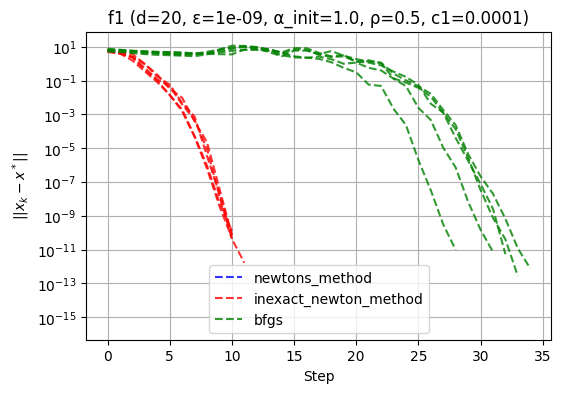

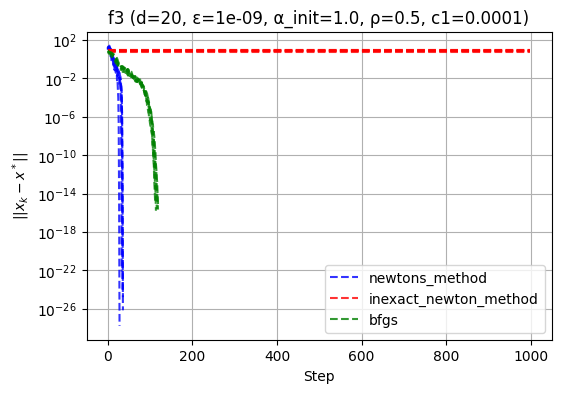

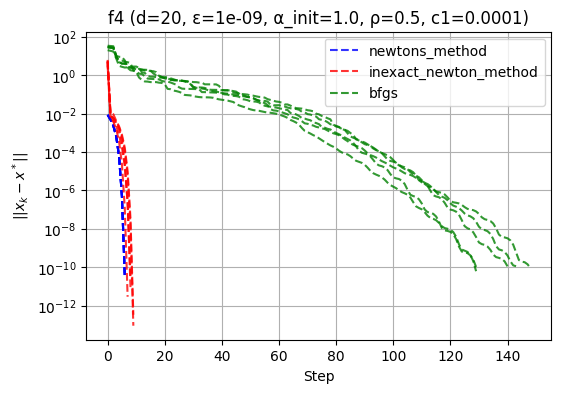

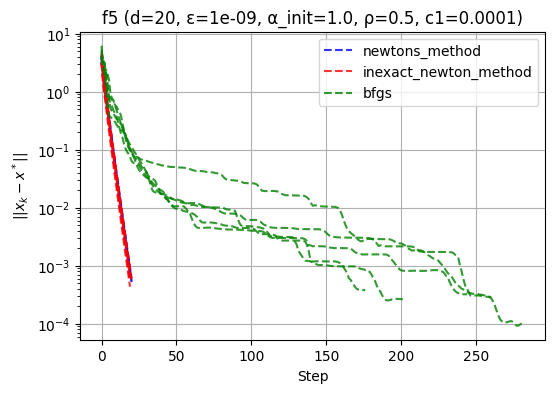

In [8]:
functions = [
    (f1, df1, Hf1),  
    (f3, df3, Hf3),
    (f4, df4, Hf4),
    (f5, df5, Hf5),
]

optimizers = [newtons_method, inexact_newton_method, bfgs]  

test_optimizers_on_function_distance(functions, optimizers, dimension=20, alpha_init=1.0, rho=0.5, c1=1e-4, c2=0.9, epsilon=1e-9, max_iter=1000, num_runs=5)

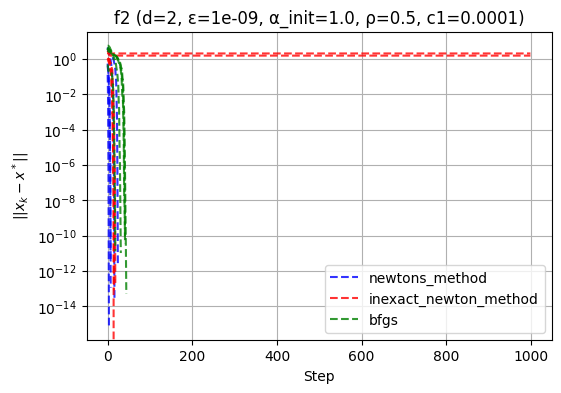

In [9]:
functions = [
    (f2, df2, Hf2)]

optimizers = [newtons_method, inexact_newton_method, bfgs]  

test_optimizers_on_function_distance(functions, optimizers, dimension=2, alpha_init=1.0, rho=0.5, c1=1e-4, c2=0.9, epsilon=1e-9, max_iter=1000, num_runs=5)

#### Convergence Plots Using Different Optimizers (time instead of steps)

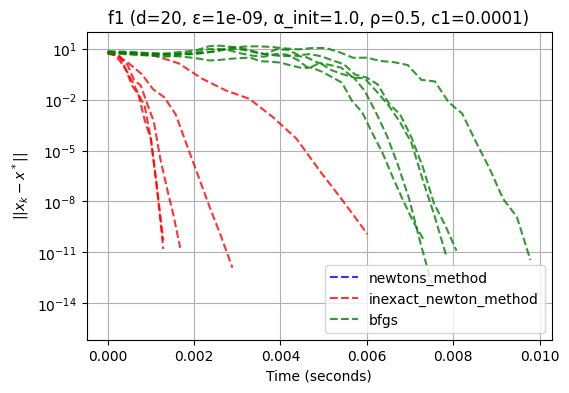

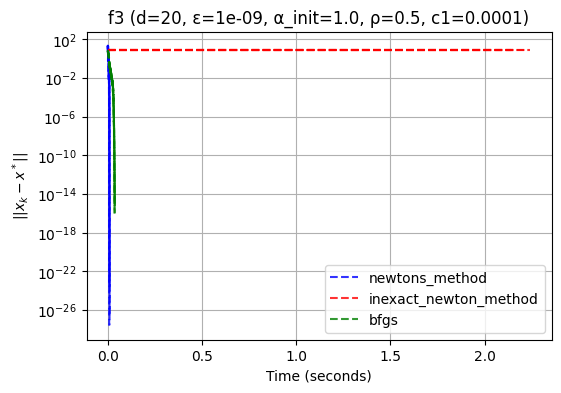

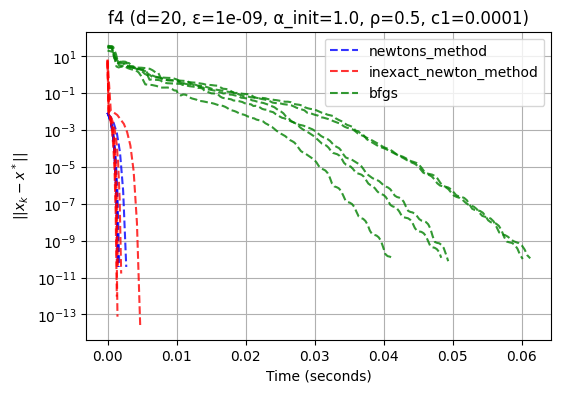

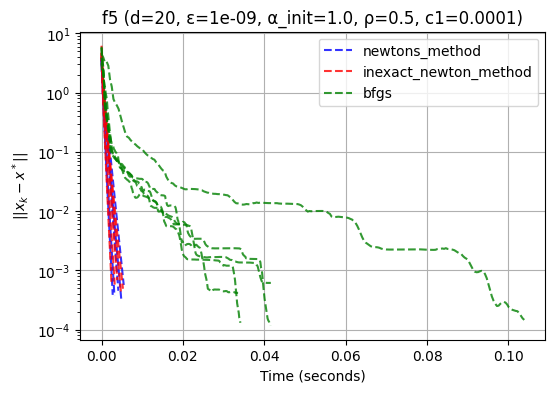

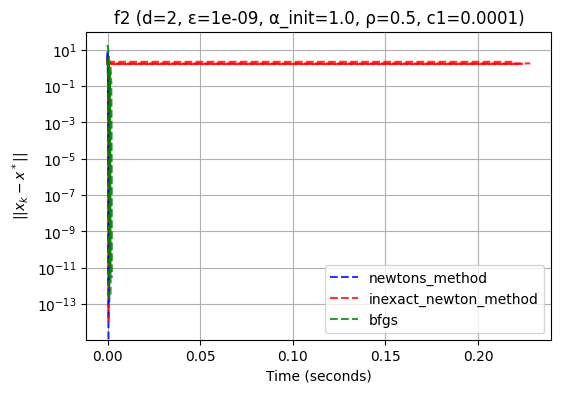

In [11]:
import time

def test_optimizers_on_function_distance(functions, optimizers, dimension=20, alpha_init=1.0, rho=0.5, c1=1e-4, c2=0.9, epsilon=1e-9, max_iter=1000, num_runs=5):

    colors = ['b', 'red', 'green', 'orange', 'purple']  # Assign unique colors for each run

    for f, df, Hf in functions:
        plt.figure(figsize=(6, 4))
        plt.title(f"{f.__name__} (d={dimension}, ε={epsilon:.0e}, α_init={alpha_init}, ρ={rho}, c1={c1})")

        for opt_idx, opt in enumerate(optimizers):
            color = colors[opt_idx % len(colors)]  # Assign color based on optimizer index

            for run in range(num_runs):
                x0 = np.random.uniform(-3, 3, size=dimension)  # Generate a random starting point
                
                # Measure time for each iteration
                start_time = time.time()
                
                if opt == bfgs:
                    xs, _ = opt(f, df, x0, c1, c2, epsilon, max_iter)
                elif opt == scipy_bfgs:
                    xs, _ = opt(f, df, x0, max_iter, epsilon)
                elif opt == newtons_method:
                    xs, _ = opt(f, df, Hf, x0, epsilon, max_iter, alpha_init, rho, c1)
                elif opt == inexact_newton_method:
                    xs, _ = opt(f, df, Hf, x0, epsilon, max_iter, alpha_init, rho, c1, eta_schedule="superlinear")
                
                end_time = time.time()
                total_time = end_time - start_time
                
                # Compute distances to optimum
                optimal = x_opt(f.__name__, dimension)
                distances = [np.linalg.norm(x - optimal) for x in xs]
                
                # Create time points for each iteration
                # Assuming uniform time distribution across iterations
                times = np.linspace(0, total_time, len(distances))

                # Plot the distances for each run
                label = f"{opt.__name__}" if run == 0 else ""
                plt.plot(times, distances, linestyle='--', color=color, alpha=0.8, label=label)

        plt.xlabel("Time (seconds)")
        plt.ylabel(r"$||x_k - x^*||$")
        plt.yscale("log")  # Log scale
        plt.grid()
        plt.legend()
        plt.show()

functions = [
    (f1, df1, Hf1),  
    (f3, df3, Hf3),
    (f4, df4, Hf4),
    (f5, df5, Hf5),
]

optimizers = [newtons_method, inexact_newton_method, bfgs]  

test_optimizers_on_function_distance(functions, optimizers, dimension=20, alpha_init=1.0, rho=0.5, c1=1e-4, c2=0.9, epsilon=1e-9, max_iter=1000, num_runs=5)

functions = [
    (f2, df2, Hf2)]

optimizers = [newtons_method, inexact_newton_method, bfgs]  

test_optimizers_on_function_distance(functions, optimizers, dimension=2, alpha_init=1.0, rho=0.5, c1=1e-4, c2=0.9, epsilon=1e-9, max_iter=1000, num_runs=5)

### Convergence Plots Comparing BFGS and Scipy BFGS

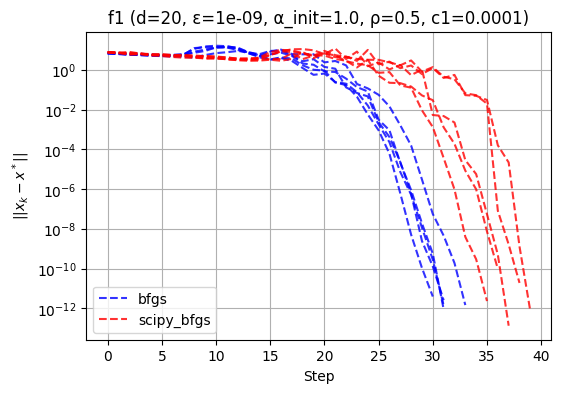

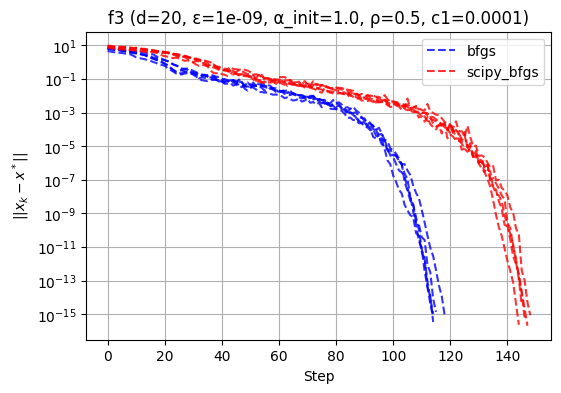

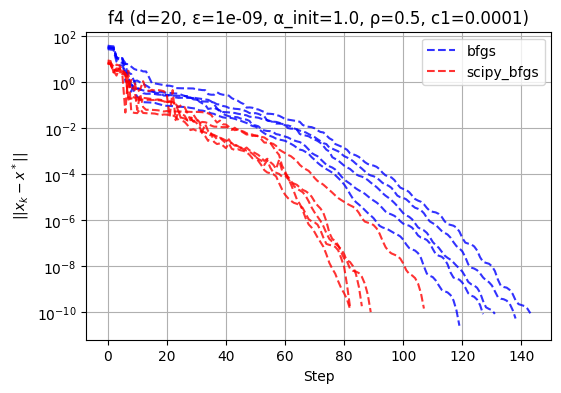

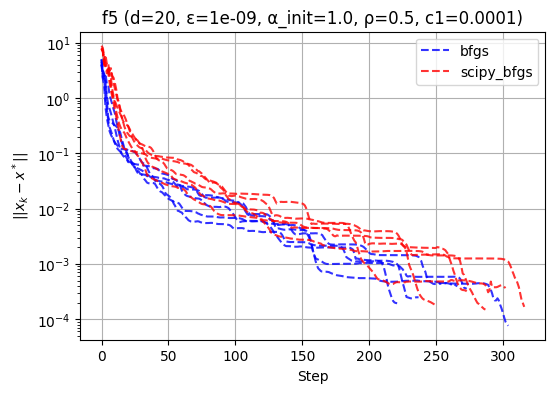

In [118]:
functions = [
    (f1, df1, Hf1),  
    (f3, df3, Hf3),
    (f4, df4, Hf4),
    (f5, df5, Hf5),
]

optimizers = [bfgs, scipy_bfgs]  

test_optimizers_on_function_distance(functions, optimizers, dimension=20, alpha_init=1.0, rho=0.5, c1=1e-4, c2=0.9, epsilon=1e-9, max_iter=1000, num_runs=5)

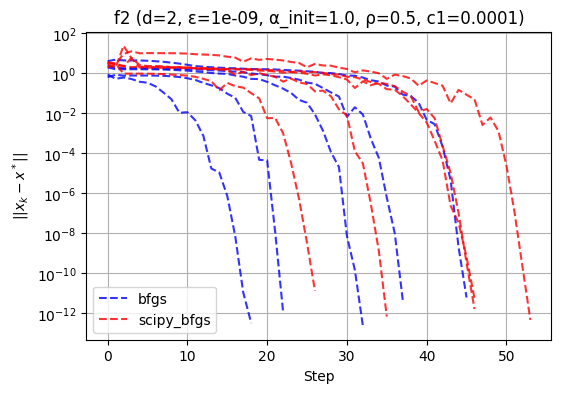

In [119]:
functions = [
    (f2, df2, Hf2)
]

optimizers = [bfgs, scipy_bfgs]  

test_optimizers_on_function_distance(functions, optimizers, dimension=2, alpha_init=1.0, rho=0.5, c1=1e-4, c2=0.9, epsilon=1e-9, max_iter=1000, num_runs=5)

#### Line Search Behaviors Plots (1 random x0)

In [120]:
def wolfe_search(f, grad_f, xk, pk, alpha_init=1.0, c1=1e-4, c2=0.9):
    def g(alpha):
        return f(xk + alpha * pk)
    
    def g_prime(alpha):
        return np.dot(grad_f(xk + alpha * pk), pk)  # g'(alpha)
    
    l, u = 0, alpha_init
    alphas = [alpha_init]  # Track the alpha values 
    
    while True:
        if g(u) > g(0) + c1 * u * g_prime(0) or g(u) > g(l):
            break
        if abs(g_prime(u)) < c2 * abs(g_prime(0)):
            alphas.append(u)
            return u, alphas
        if g_prime(u) > 0:
            break
        else:
            u *= 2
            alphas.append(u)
    
    while True:
        a = (l + u) / 2
        alphas.append(a)
        if g(a) > g(0) + c1 * a * g_prime(0) or g(a) > g(l):
            u = a
        else:
            if abs(g_prime(a)) < c2 * abs(g_prime(0)):
                alphas.append(a)
                return a, alphas
            if g_prime(a) < 0:
                l = a
            else:
                u = a

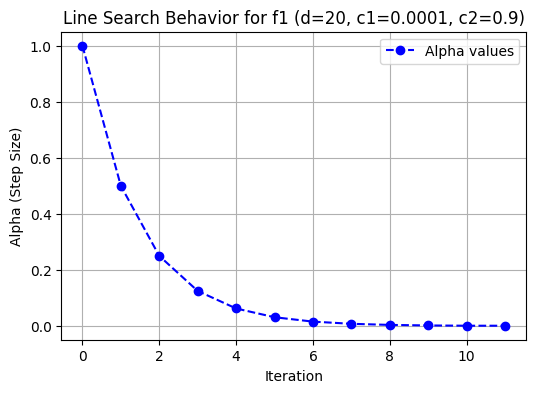

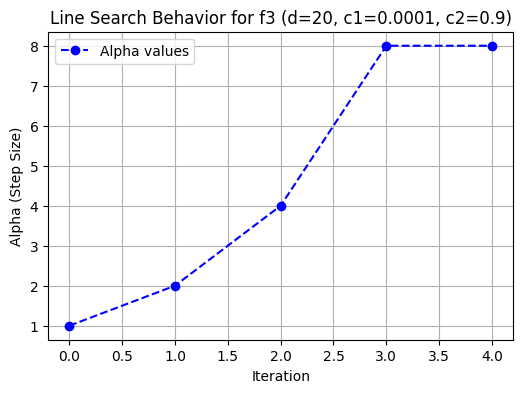

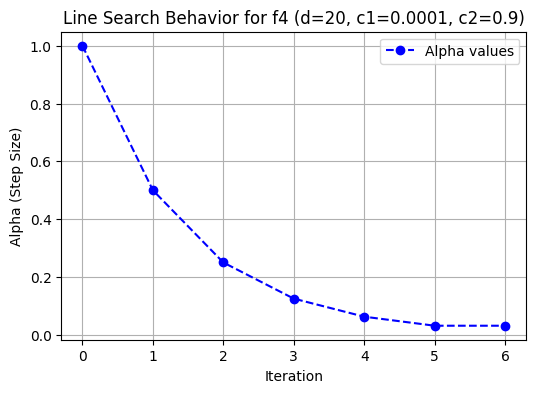

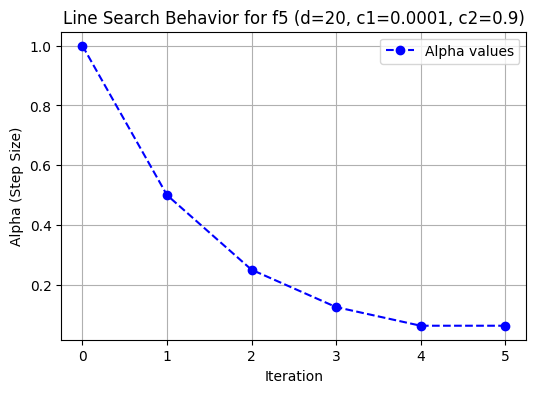

In [121]:
import numpy as np
import matplotlib.pyplot as plt

def test_line_search_for_functions(functions, dimension=20, c1=1e-4, c2=0.9):
    """
    Test Wolfe line search on a set of functions using BFGS-style search direction.
    Plots the step sizes (alpha) for a single run per function.

    Parameters:
    - functions: List of tuples (function_name, function, gradient)
    - dimension: Dimension of the problem (default: 20)
    - c1, c2: Wolfe line search parameters (default: 1e-4, 0.9)
    """
    for func_name, f, df in functions:
        plt.figure(figsize=(6, 4))
        plt.title(f"Line Search Behavior for {func_name} (d={dimension}, c1={c1}, c2={c2})")

        # Generate a random starting point
        x0 = np.random.uniform(-3, 3, size=dimension)
        
        # Initialize Hessian approximation (identity matrix)
        Hk = np.eye(dimension)  

        # BFGS search direction
        pk = -Hk @ df(x0)

        alpha, alphas = wolfe_search(f, df, x0, pk, c1=c1, c2=c2)

        plt.plot(range(len(alphas)), alphas, linestyle='--', marker='o', color='b', label="Alpha values")

        plt.xlabel('Iteration')
        plt.ylabel('Alpha (Step Size)')
        plt.grid(True)
        plt.legend()
        plt.show()

functions = [
    ("f1", f1, df1),
    ("f3", f3, df3),
    ("f4", f4, df4),
    ("f5", f5, df5)
]

test_line_search_for_functions(functions, dimension=20, c1=1e-4, c2=0.9)


#### Line Search Behaviors Plots (100 random x0)

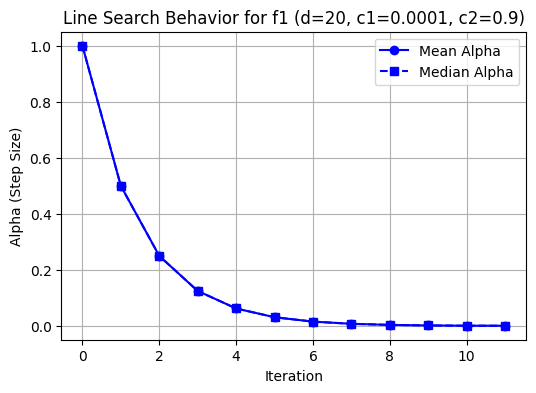

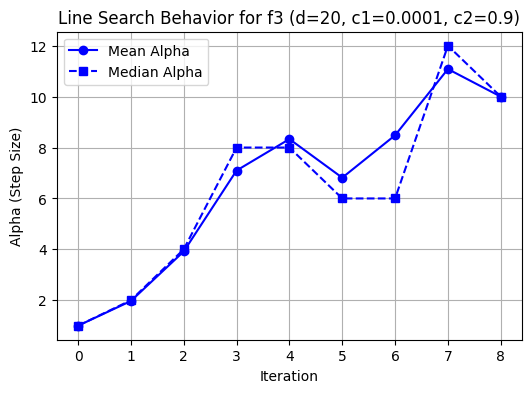

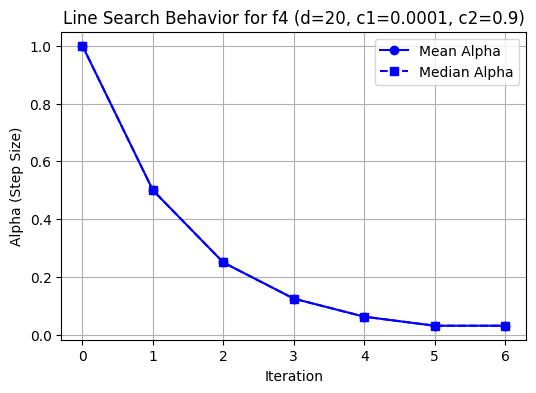

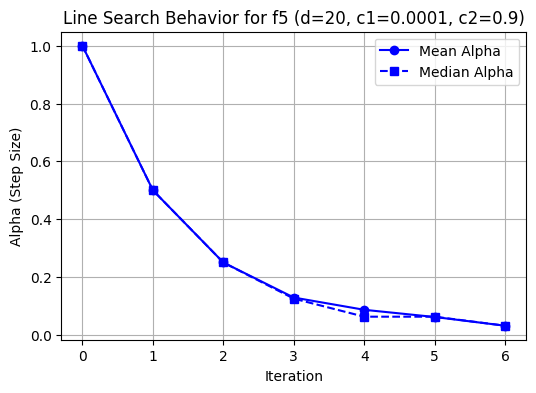

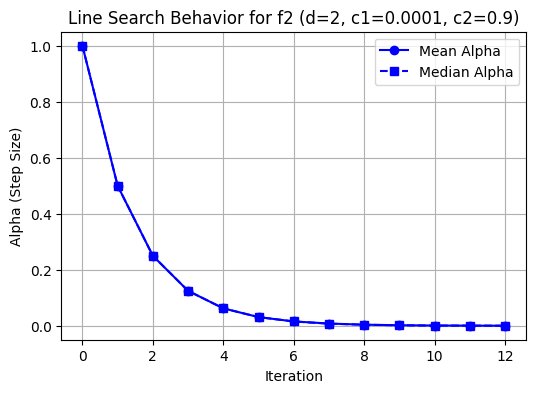

In [124]:
import numpy as np
import matplotlib.pyplot as plt

def test_line_search_for_functions(functions, dimension=20, c1=1e-4, c2=0.9, num_runs=5):
    """
    Test Wolfe line search on a set of functions using BFGS-style search direction.
    Plots mean and median of step sizes (alpha) over multiple runs.

    Parameters:
    - functions: List of tuples (function_name, function, gradient)
    - dimension: Dimension of the problem (default: 20)
    - c1, c2: Wolfe line search parameters (default: 1e-4, 0.9)
    - num_runs: Number of runs with different random initializations (default: 5)
    """
    for func_name, f, df in functions:
        plt.figure(figsize=(6, 4))
        plt.title(f"Line Search Behavior for {func_name} (d={dimension}, c1={c1}, c2={c2})")

        all_alphas = []  # Store all alphas across runs

        for run in range(num_runs):
            # Generate a random starting point
            x0 = np.random.uniform(-3, 3, size=dimension)
            
            # Initialize Hessian approximation (identity matrix)
            Hk = np.eye(dimension)  

            # BFGS search direction
            pk = -Hk @ df(x0)

            alpha, alphas = wolfe_search(f, df, x0, pk, c1=c1, c2=c2)

            all_alphas.append(alphas)

        max_length = max(map(len, all_alphas))
        all_alphas = np.array([np.pad(a, (0, max_length - len(a)), constant_values=np.nan) for a in all_alphas])

        # Compute mean and median, ignoring NaN values
        mean_alphas = np.nanmean(all_alphas, axis=0)
        median_alphas = np.nanmedian(all_alphas, axis=0)

        plt.plot(mean_alphas, linestyle='-', marker='o', color='b', label="Mean Alpha")
        plt.plot(median_alphas, linestyle='--', marker='s', color='b', label="Median Alpha")

        plt.xlabel('Iteration')
        plt.ylabel('Alpha (Step Size)')
        plt.grid(True)
        plt.legend()
        plt.show()


functions = [
    ("f1", f1, df1),
    ("f3", f3, df3),
    ("f4", f4, df4),
    ("f5", f5, df5)
]

test_line_search_for_functions(functions, dimension=20, c1=1e-4, c2=0.9, num_runs=100)

functions =  [
    ("f2", f2, df2),
]
test_line_search_for_functions(functions, dimension=2, c1=1e-4, c2=0.9, num_runs=100)